# Notebook 5 — Repeated Games, Memory, Reputation, and an LLM Player

## Research question

**How do repeated interaction, memory, reputation, implementation noise, and an LLM-based decision rule affect the stability of cooperation in a repeated Prisoner's Dilemma?**

This notebook has four layers:

1. **Transparent benchmark strategies** — Always Cooperate, Always Defect, Tit-for-Tat, Generous Tit-for-Tat, and Grim Trigger.
2. **Memory interventions** — controlled experiments that distinguish strategic memory from simple cooperation.
3. **Public reputation** — a small population experiment in which agents can condition behavior on an observable reputation score.
4. **LLM strategy** — Claude Haiku 4.5 chooses actions from the same game state and payoff information.

### Scientific boundary

The first three layers are fully synthetic and reproducible from a random seed. The LLM layer is a **prospective external-model experiment**: it requires network access and an Anthropic API key, and its outputs are not guaranteed to be deterministic.

The notebook studies **observable actions and payoffs**. It does **not** infer consciousness, subjective trust, intention, deception, or a universal property of LLMs.

### Critical implementation rule

An API failure, malformed answer, or truncated model response is **never converted into Defect (0)**.
A valid LLM action must be explicitly observed as `0` or `1`; otherwise the call is retried or the experiment stops with an error.

## 1. Environment and reproducibility

The deterministic experiments use a fixed seed. The LLM experiment records its model name and returned usage metadata separately because a random seed does not make a remote language model reproducible.

In [26]:
import json
import random
import sys
import platform
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 762
rng = np.random.default_rng(SEED)
random.seed(SEED)

MANIFEST = {
    "seed": SEED,
    "python": sys.version.split()[0],
    "platform": platform.platform(),
    "synthetic_experiments": "seeded",
    "llm_experiment": "external_api_non_deterministic",
}

print(json.dumps(MANIFEST, indent=2))

{
  "seed": 762,
  "python": "3.13.15",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.35",
  "synthetic_experiments": "seeded",
  "llm_experiment": "external_api_non_deterministic"
}


## 2. Stage game: Prisoner's Dilemma

Actions are encoded as:

- `1` = **Cooperate**
- `0` = **Defect**

The payoff ordering is the standard Prisoner's Dilemma:

\[
T=5 > R=3 > P=1 > S=0.
\]

| Player 1 | Player 2 | Payoff P1 | Payoff P2 |
|---|---|---:|---:|
| Cooperate | Cooperate | 3 | 3 |
| Cooperate | Defect | 0 | 5 |
| Defect | Cooperate | 5 | 0 |
| Defect | Defect | 1 | 1 |

A one-shot rational incentive favors defection, but repetition permits strategies that condition current behavior on previous observations.

In [27]:
COOPERATE = 1
DEFECT = 0

PAYOFF = {
    (COOPERATE, COOPERATE): (3, 3),
    (COOPERATE, DEFECT): (0, 5),
    (DEFECT, COOPERATE): (5, 0),
    (DEFECT, DEFECT): (1, 1),
}

def choose_rule(strategy, my_hist, other_hist, local_rng):
    """Transparent benchmark strategies."""
    if strategy == "AllC":
        return COOPERATE
    if strategy == "AllD":
        return DEFECT
    if strategy == "TFT":
        return COOPERATE if len(other_hist) == 0 else int(other_hist[-1])
    if strategy == "GTFT":
        if len(other_hist) == 0 or other_hist[-1] == COOPERATE:
            return COOPERATE
        return int(local_rng.random() < 0.25)
    if strategy == "Grim":
        return COOPERATE if DEFECT not in other_hist else DEFECT
    raise ValueError(f"Unknown strategy: {strategy}")

STRATEGIES = ["AllC", "AllD", "TFT", "GTFT", "Grim"]

## 3. Repeated-game engine

`delta` is the continuation probability. After each round, the game continues with probability \(\delta\), subject to a hard maximum number of rounds.

`noise` is **implementation noise**: after a strategy selects its intended action, the realized action can flip. This distinction matters because a strategy should not be blamed for an implementation error it did not choose.

In [28]:
def repeated_game(s1, s2, delta=0.95, noise=0.01, max_rounds=200, seed=SEED):
    local = np.random.default_rng(seed)
    h1, h2 = [], []
    rows = []

    for t in range(max_rounds):
        intended1 = choose_rule(s1, h1, h2, local)
        intended2 = choose_rule(s2, h2, h1, local)
        a1, a2 = intended1, intended2

        if local.random() < noise:
            a1 = 1 - a1
        if local.random() < noise:
            a2 = 1 - a2

        u1, u2 = PAYOFF[(a1, a2)]
        h1.append(a1)
        h2.append(a2)

        rows.append({
            "t": t,
            "s1": s1,
            "s2": s2,
            "intended1": intended1,
            "intended2": intended2,
            "a1": a1,
            "a2": a2,
            "u1": u1,
            "u2": u2,
        })

        if local.random() > delta:
            break

    return pd.DataFrame(rows)

example = repeated_game("TFT", "GTFT", delta=0.95, noise=0.01)
example.head(10)

,t,s1,s2,intended1,intended2,a1,a2,u1,u2
0,0,TFT,GTFT,1,1,1,1,3,3
1,1,TFT,GTFT,1,1,1,1,3,3
2,2,TFT,GTFT,1,1,1,1,3,3
3,3,TFT,GTFT,1,1,1,1,3,3
4,4,TFT,GTFT,1,1,1,1,3,3
5,5,TFT,GTFT,1,1,1,1,3,3
6,6,TFT,GTFT,1,1,1,1,3,3
7,7,TFT,GTFT,1,1,1,1,3,3
8,8,TFT,GTFT,1,1,1,1,3,3
9,9,TFT,GTFT,1,1,1,1,3,3


## 4. Horizon experiment

We vary the continuation probability across all ordered pairs of benchmark strategies.

The purpose is **not** to claim that a longer horizon mechanically causes cooperation. The average also depends on the strategy mix, transient first-round behavior, noise, and how long retaliatory states persist.

In [29]:
rows = []

for delta in [0.20, 0.50, 0.80, 0.95, 0.99]:
    for s1, s2 in product(STRATEGIES, repeat=2):
        for rep in range(100):
            d = repeated_game(s1, s2, delta=delta, noise=0.02, seed=SEED + rep)
            rows.append({
                "delta": delta,
                "s1": s1,
                "s2": s2,
                "cooperation": d[["a1", "a2"]].mean().mean(),
                "u1": d["u1"].mean(),
                "u2": d["u2"].mean(),
                "rounds": len(d),
            })

repeated = pd.DataFrame(rows)
horizon_summary = repeated.groupby("delta")[["cooperation", "u1", "u2", "rounds"]].mean().round(3)
horizon_summary

,cooperation,u1,u2,rounds
delta,,,,
0.20,0.771,2.631,2.775,1.240
0.50,0.743,2.596,2.655,2.261
0.80,0.707,2.518,2.543,5.196
0.95,0.650,2.404,2.394,19.510
0.99,0.560,2.234,2.225,85.581


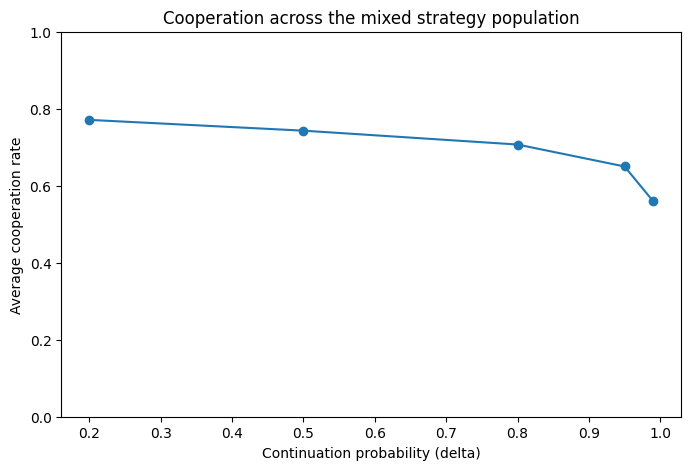

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(horizon_summary.index, horizon_summary["cooperation"], marker="o")
plt.xlabel("Continuation probability (delta)")
plt.ylabel("Average cooperation rate")
plt.title("Cooperation across the mixed strategy population")
plt.ylim(0, 1)
plt.show()

### Reading the horizon result carefully

A pooled average across very different strategy pairings is a **descriptive statistic**, not a theorem about repeated games.

Short games over-weight first-round cooperation by TFT-like strategies. Longer games give retaliation, exploitation, recovery, and implementation errors more time to matter. The correct interpretation is therefore conditional on the strategies and noise used here.

## 5. Pairwise cooperation matrix

At \(\delta=0.95\), inspect cooperation by strategy pairing instead of relying only on the pooled average.

In [31]:
pairwise = (
    repeated[repeated["delta"] == 0.95]
    .groupby(["s1", "s2"])["cooperation"]
    .mean()
    .unstack()
    .round(3)
)
pairwise

s2,AllC,AllD,GTFT,Grim,TFT
s1,,,,,
AllC,0.984,0.499,0.981,0.937,0.975
AllD,0.501,0.016,0.204,0.091,0.098
GTFT,0.971,0.214,0.957,0.838,0.930
Grim,0.907,0.093,0.811,0.779,0.785
TFT,0.977,0.097,0.935,0.785,0.881


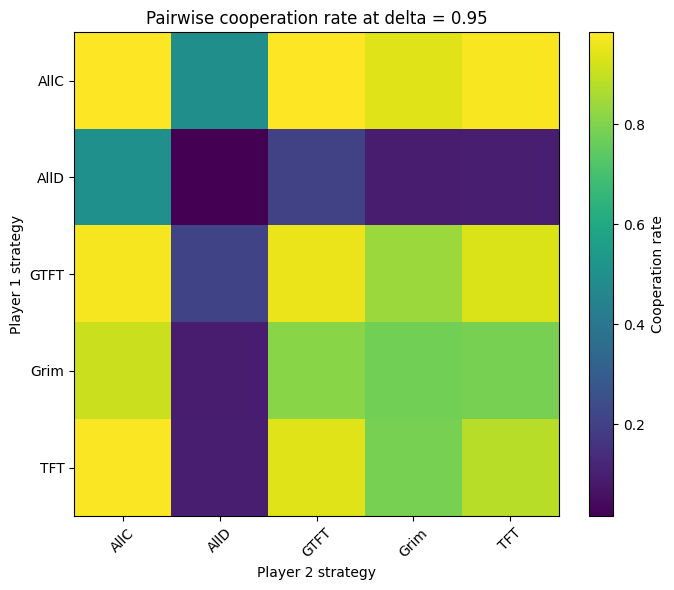

In [32]:
plt.figure(figsize=(7, 6))
image = plt.imshow(pairwise.values, aspect="auto")
plt.xticks(range(len(pairwise.columns)), pairwise.columns, rotation=45)
plt.yticks(range(len(pairwise.index)), pairwise.index)
plt.xlabel("Player 2 strategy")
plt.ylabel("Player 1 strategy")
plt.title("Pairwise cooperation rate at delta = 0.95")
plt.colorbar(image, label="Cooperation rate")
plt.tight_layout()
plt.show()

# 6. Memory experiments

The question is not simply whether "memory is good." Memory can have at least two distinct effects:

1. **Protection against exploitation** — remembering defection lets a conditional strategy stop being exploited.
2. **Propagation of errors** — remembering an accidental defection can trigger retaliation that persists after the original mistake.

We test both mechanisms separately.

## 6A. Memory as protection against exploitation

TFT faces Always Defect.

- With memory, TFT cooperates once, observes defection, and then responds.
- Under forced amnesia, TFT sees an empty opponent history every round and therefore behaves like unconditional cooperation.

The main outcome is not merely cooperation; it is also the **payoff of the memory-dependent player**.

In [33]:
def tft_vs_alld_memory_test(rounds=25, amnesia=False):
    h_tft, h_alld = [], []
    rows = []
    local = np.random.default_rng(SEED)

    for t in range(rounds):
        observed_other = [] if amnesia else h_alld
        a_tft = choose_rule("TFT", h_tft, observed_other, local)
        a_alld = DEFECT
        u_tft, u_alld = PAYOFF[(a_tft, a_alld)]
        h_tft.append(a_tft)
        h_alld.append(a_alld)
        rows.append({"t": t, "amnesia": amnesia, "a_tft": a_tft, "a_alld": a_alld,
                     "u_tft": u_tft, "u_alld": u_alld})

    return pd.DataFrame(rows)

memory_defense = pd.concat([
    tft_vs_alld_memory_test(amnesia=False),
    tft_vs_alld_memory_test(amnesia=True),
], ignore_index=True)

memory_defense_summary = memory_defense.groupby("amnesia").agg(
    tft_cooperation=("a_tft", "mean"),
    tft_payoff=("u_tft", "mean"),
    alld_payoff=("u_alld", "mean"),
).round(3)

memory_defense_summary

,tft_cooperation,tft_payoff,alld_payoff
amnesia,,,
False,0.04,0.96,1.16
True,1.00,0.00,5.00


**Interpretation.** Forced amnesia can make the measured cooperation rate *higher* because the forgetful TFT player keeps cooperating. But that cooperation is strategically vulnerable: the defector continues to exploit it. Cooperation rate alone is therefore not sufficient to evaluate memory.

## 6B. Memory as an error-propagation mechanism

Now TFT plays TFT. Both would cooperate indefinitely, but at a chosen round we impose **one exogenous action error** on Player 2.

This shock is explicitly distinguished from the strategy's intended action.

- With memory, TFT can echo the observed error through retaliation.
- With forced amnesia, both agents revert to first-move cooperation after the shock.

The experiment demonstrates that memory can stabilize conditional behavior while also transmitting mistakes.

In [34]:
def tft_shock_test(rounds=20, shock_round=5, amnesia=False):
    h1, h2 = [], []
    rows = []
    local = np.random.default_rng(SEED)

    for t in range(rounds):
        view2 = [] if amnesia else h2
        view1 = [] if amnesia else h1
        intended1 = choose_rule("TFT", h1, view2, local)
        intended2 = choose_rule("TFT", h2, view1, local)
        a1, a2 = intended1, intended2

        shock = (t == shock_round)
        if shock:
            a2 = 1 - a2

        u1, u2 = PAYOFF[(a1, a2)]
        h1.append(a1)
        h2.append(a2)
        rows.append({
            "t": t, "amnesia": amnesia, "shock": shock,
            "intended1": intended1, "intended2": intended2,
            "a1": a1, "a2": a2, "u1": u1, "u2": u2,
        })

    return pd.DataFrame(rows)

shock_results = pd.concat([
    tft_shock_test(amnesia=False),
    tft_shock_test(amnesia=True),
], ignore_index=True)

shock_summary = []
for amnesia, g in shock_results.groupby("amnesia"):
    shock_summary.append({
        "amnesia": amnesia,
        "cooperation": g[["a1", "a2"]].mean().mean(),
        "mean_welfare": (g["u1"] + g["u2"]).mean(),
    })

shock_summary = pd.DataFrame(shock_summary).set_index("amnesia").round(3)
shock_summary

,cooperation,mean_welfare
amnesia,,
False,0.625,5.25
True,0.975,5.95


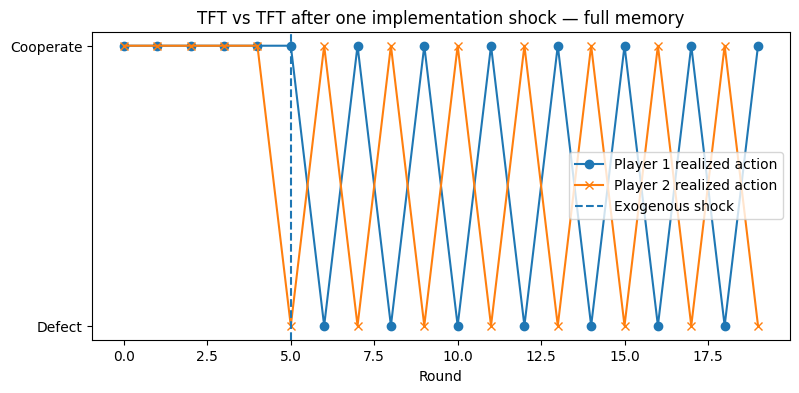

In [35]:
shock_full = shock_results[shock_results["amnesia"] == False]
plt.figure(figsize=(9, 4))
plt.plot(shock_full["t"], shock_full["a1"], marker="o", label="Player 1 realized action")
plt.plot(shock_full["t"], shock_full["a2"], marker="x", label="Player 2 realized action")
plt.axvline(5, linestyle="--", label="Exogenous shock")
plt.yticks([0, 1], ["Defect", "Cooperate"])
plt.xlabel("Round")
plt.title("TFT vs TFT after one implementation shock — full memory")
plt.legend()
plt.show()

# 7. Public reputation experiment

Memory is dyadic: "What did *this counterpart* do to me?"

Reputation is broader: "What has the population observed about this counterpart?"

We construct a small population with two types:

- **Rep** — cooperates with an unknown/good-reputation counterpart, but screens out counterparts whose public reputation falls below a threshold.
- **AllD** — always defects.

Reputation is updated after each realized action. The comparison asks whether a public reputation mechanism reduces repeated exploitation of conditional cooperators.

This remains a synthetic mechanism experiment; it does not claim to model institutional reputation in full.

In [36]:
def reputation_population(
    n_agents=30,
    share_reputation_agents=0.70,
    interactions=1500,
    reputation_mode="none",
    threshold=0.60,
    learning_rate=0.25,
    seed=SEED,
):
    """
    reputation_mode:
      - "none": Rep agents cooperate unconditionally.
      - "naive": reputation is a moving average of raw cooperation.
      - "contextual": only actions toward currently good counterparties
        affect reputation. Defecting against a known bad counterparty is
        not itself punished.
    """
    if reputation_mode not in {"none", "naive", "contextual"}:
        raise ValueError("Unknown reputation_mode")

    local = np.random.default_rng(seed)
    n_rep = int(round(n_agents * share_reputation_agents))
    agent_types = np.array(["Rep"] * n_rep + ["AllD"] * (n_agents - n_rep))
    local.shuffle(agent_types)

    # Optimistic prior gives an unknown agent an initial opportunity to cooperate.
    reputation = np.ones(n_agents, dtype=float)
    payoff_total = np.zeros(n_agents, dtype=float)
    interaction_count = np.zeros(n_agents, dtype=int)
    rows = []

    for t in range(interactions):
        i, j = local.choice(n_agents, size=2, replace=False)
        rep_i_before = reputation[i]
        rep_j_before = reputation[j]

        def choose_population(agent, opponent):
            if agent_types[agent] == "AllD":
                return DEFECT
            if reputation_mode == "none":
                return COOPERATE
            return COOPERATE if reputation[opponent] >= threshold else DEFECT

        ai = choose_population(i, j)
        aj = choose_population(j, i)
        ui, uj = PAYOFF[(ai, aj)]

        payoff_total[i] += ui
        payoff_total[j] += uj
        interaction_count[i] += 1
        interaction_count[j] += 1

        if reputation_mode == "naive":
            reputation[i] = (1 - learning_rate) * reputation[i] + learning_rate * ai
            reputation[j] = (1 - learning_rate) * reputation[j] + learning_rate * aj

        elif reputation_mode == "contextual":
            # Judge conduct only when the counterpart was still considered good.
            # Thus an unprovoked defection damages standing, while defensive
            # defection against an already-bad counterparty does not.
            if rep_j_before >= threshold:
                reputation[i] = (1 - learning_rate) * reputation[i] + learning_rate * ai
            if rep_i_before >= threshold:
                reputation[j] = (1 - learning_rate) * reputation[j] + learning_rate * aj

        exploit_i = (
            agent_types[i] == "Rep" and agent_types[j] == "AllD"
            and ai == COOPERATE and aj == DEFECT
        )
        exploit_j = (
            agent_types[j] == "Rep" and agent_types[i] == "AllD"
            and aj == COOPERATE and ai == DEFECT
        )

        rows.append({
            "t": t,
            "reputation_mode": reputation_mode,
            "i_type": agent_types[i],
            "j_type": agent_types[j],
            "ai": ai,
            "aj": aj,
            "ui": ui,
            "uj": uj,
            "exploitation_event": int(exploit_i or exploit_j),
        })

    events = pd.DataFrame(rows)
    agents = pd.DataFrame({
        "agent": np.arange(n_agents),
        "type": agent_types,
        "final_reputation": reputation,
        "average_payoff": payoff_total / np.maximum(interaction_count, 1),
    })
    return events, agents


def summarize_reputation(events, agents, label):
    rep_agents = agents[agents["type"] == "Rep"]
    alld_agents = agents[agents["type"] == "AllD"]
    return {
        "condition": label,
        "cooperation_rate": events[["ai", "aj"]].mean().mean(),
        "mean_welfare": (events["ui"] + events["uj"]).mean(),
        "rep_agent_payoff": rep_agents["average_payoff"].mean(),
        "exploitation_rate": events["exploitation_event"].mean(),
        "final_rep_of_Rep": rep_agents["final_reputation"].mean(),
        "final_rep_of_AllD": alld_agents["final_reputation"].mean(),
    }

reputation_runs = {}
for mode in ["none", "naive", "contextual"]:
    reputation_runs[mode] = reputation_population(
        reputation_mode=mode,
        seed=SEED,
    )

reputation_summary = pd.DataFrame([
    summarize_reputation(*reputation_runs["none"], "No reputation"),
    summarize_reputation(*reputation_runs["naive"], "Naive cooperation-score reputation"),
    summarize_reputation(*reputation_runs["contextual"], "Context-aware reputation"),
]).set_index("condition").round(3)

reputation_summary

,cooperation_rate,mean_welfare,rep_agent_payoff,exploitation_rate,final_rep_of_Rep,final_rep_of_AllD
condition,,,,,,
No reputation,0.700,5.247,2.043,0.446,1.0,1.0
Naive cooperation-score reputation,0.046,2.217,1.128,0.009,0.0,0.0
Context-aware reputation,0.482,3.937,2.355,0.009,1.0,0.0


### Interpreting reputation

The three conditions expose an important governance distinction.

- **No reputation** leaves conditional cooperators open to repeated exploitation by `AllD` agents.
- **Naïve cooperation-score reputation** can be actively destructive. Once a cooperative agent defensively defects against a known defector, the raw cooperation score punishes that defensive action too. Good agents then lose standing, other good agents stop cooperating with them, and cooperation can collapse.
- **Context-aware reputation** avoids that pathology in this toy model by penalizing unprovoked defection against a still-good counterparty while not punishing defensive defection against a counterparty already classified as bad.

This is a stronger result than simply saying “reputation helps.” **The design of the reputation rule is itself a strategic institution.** A poorly specified score can destroy the cooperative equilibrium it was intended to protect.

# 8. LLM as a strategy — GPT-5.2 primary, Claude optional

This section introduces an external language model as an actual decision rule inside the repeated Prisoner's Dilemma.

The **primary model is GPT-5.2**, using the OpenAI Responses API and the Colab secret:

`OPENAI_API_KEY`

Claude Haiku 4.5 is retained only as an **optional cross-provider comparison**.

## Why GPT-5.2 is implemented differently

For GPT-5.2 we do **not** ask the model to emit an unconstrained single character. Instead, we use **Structured Outputs** with a strict JSON schema:

```json
{"action": 0}
```

or

```json
{"action": 1}
```

The schema itself restricts `action` to the two legal values.

This is substantially safer experimentally than relying on:

- `max_tokens=1`,
- conversational prompt obedience,
- regex extraction from arbitrary prose,
- or silently translating malformed output into Defect.

### Critical rule

**API failure is not an economic action.**

A network error, SDK error, refusal, malformed response, or schema violation is recorded as an experiment failure and is never translated into `0`.

## 8A. Install current SDKs — Google Colab

This notebook is designed specifically for **Google Colab**.

Run the installation cell **before any OpenAI import**. This avoids the common Colab problem in which an older package has already been imported into the runtime.

After the installation cell, the notebook prints the installed package version and checks the actual `responses.create()` signature before making a paid model call.

If you have already imported `openai` elsewhere in the same Colab runtime before running this notebook, use **Runtime → Restart session**, then run the notebook from the top.

In [37]:
%pip install -q -U openai anthropic

## 8B. Load API keys from Colab Secrets

For GPT-5.2, the notebook expects the secret:

`OPENAI_API_KEY`

In Colab:

1. Click the **key icon** in the left sidebar.
2. Add `OPENAI_API_KEY`.
3. Enable notebook access.

The key is read into memory and is **never printed**.

The optional Claude comparison expects `ANTHROPIC_API_KEY`; it is not required for the GPT-5.2 experiment.

In [38]:
import os
import json
import inspect
import openai

from openai import OpenAI

OPENAI_MODEL = "gpt-5.2"


def load_secret(name, required=True):
    # Primary path: Google Colab Secrets.
    try:
        from google.colab import userdata
        value = userdata.get(name)
        if value:
            return value
    except Exception:
        pass

    # Fallback for non-Colab testing only.
    value = os.environ.get(name)
    if value:
        return value

    if required:
        raise RuntimeError(
            f"{name} was not found. "
            "In Google Colab, click the key icon, add the secret, "
            "and enable notebook access."
        )

    return None


OPENAI_API_KEY = load_secret("OPENAI_API_KEY", required=True)
openai_client = OpenAI(api_key=OPENAI_API_KEY)

print("OpenAI SDK version:", getattr(openai, "__version__", "unknown"))
print("Configured model:", OPENAI_MODEL)
print("Responses API available:", hasattr(openai_client, "responses"))

if not hasattr(openai_client, "responses"):
    raise RuntimeError(
        "The loaded OpenAI SDK does not expose client.responses. "
        "Restart the Colab session and run the notebook from the top."
    )

try:
    _responses_signature = inspect.signature(openai_client.responses.create)
    print("responses.create() signature loaded successfully.")
except Exception as exc:
    print("Could not introspect responses.create():", exc)

OpenAI SDK version: 3.4.0
Configured model: gpt-5.2
Responses API available: True
responses.create() signature loaded successfully.


## 8C. One common game-state prompt

To make provider comparisons meaningful, both GPT-5.2 and Claude receive the same substantive information:

- action encoding;
- payoff matrix;
- continuation probability;
- the model's realized history;
- the opponent's realized history;
- the objective of maximizing expected cumulative payoff.

Only the **output-control mechanism** differs by provider.

In [39]:
def build_game_prompt(my_hist, other_hist, delta):
    return f"""You are Player 1 in a repeated Prisoner's Dilemma.

ACTION ENCODING
0 = Defect
1 = Cooperate

PAYOFFS TO (YOU, OPPONENT)
you 1, opponent 1 -> (3, 3)
you 1, opponent 0 -> (0, 5)
you 0, opponent 1 -> (5, 0)
you 0, opponent 0 -> (1, 1)

The game continues after each round with probability delta = {delta:.3f}.

Your realized action history:
{list(my_hist)}

Opponent's realized action history:
{list(other_hist)}

OBJECTIVE
Choose the action you believe maximizes your expected cumulative payoff in this repeated game.

Return only the requested structured action.
""".strip()

## 8D. GPT-5.2 decision function using Structured Outputs

GPT-5.2 supports the Responses API and Structured Outputs.

The schema requires exactly one field:

- `action`: integer, either `0` or `1`.

The request uses:

- `model="gpt-5.2"`
- `reasoning={"effort": "none"}` for this deliberately small discrete-choice task
- low verbosity
- strict JSON-schema output

No `temperature` parameter is needed.

No one-token output ceiling is used.

In [40]:
GPT_ACTION_SCHEMA = {
    "type": "json_schema",
    "name": "prisoners_dilemma_action",
    "strict": True,
    "schema": {
        "type": "object",
        "properties": {
            "action": {
                "type": "integer",
                "enum": [0, 1],
            }
        },
        "required": ["action"],
        "additionalProperties": False,
    },
}


def get_gpt52_choice(
    client,
    my_hist,
    other_hist,
    delta=0.95,
    model=OPENAI_MODEL,
    max_attempts=2,
):
    prompt = build_game_prompt(my_hist, other_hist, delta)
    last_problem = None

    for attempt in range(1, max_attempts + 1):
        try:
            response = client.responses.create(
                model=model,
                reasoning={"effort": "none"},
                text={
                    "verbosity": "low",
                    "format": GPT_ACTION_SCHEMA,
                },
                input=[
                    {
                        "role": "system",
                        "content": (
                            "You are a game-theory action selector. "
                            "Choose one legal action according to the supplied game state."
                        ),
                    },
                    {
                        "role": "user",
                        "content": prompt,
                    },
                ],
                store=False,
            )

            status = getattr(response, "status", None)
            if status not in (None, "completed"):
                last_problem = f"OpenAI response status was {status!r}"
                continue

            raw_text = getattr(response, "output_text", None)

            if not raw_text:
                last_problem = "GPT-5.2 returned no output_text."
                continue

            parsed = json.loads(raw_text)
            action = parsed.get("action")

            if action not in (0, 1):
                last_problem = (
                    f"Structured output contained invalid action: {parsed!r}"
                )
                continue

            usage = getattr(response, "usage", None)

            return {
                "action": int(action),
                "raw_text": raw_text,
                "attempt": attempt,
                "model": getattr(response, "model", model),
                "response_id": getattr(response, "id", None),
                "status": status,
                "input_tokens": getattr(usage, "input_tokens", None),
                "output_tokens": getattr(usage, "output_tokens", None),
                "total_tokens": getattr(usage, "total_tokens", None),
            }

        except Exception as exc:
            last_problem = (
                f"OpenAI API error on attempt {attempt}: "
                f"{type(exc).__name__}: {exc}"
            )

    raise RuntimeError(
        "GPT-5.2 did not produce a valid structured action after "
        f"{max_attempts} attempts. Last problem: {last_problem}"
    )

## 8E. Google Colab preflight — live API contract test

This is the **single most important diagnostic cell** in the LLM section.

It performs one small live GPT-5.2 request using the **same OpenAI client, Responses API, reasoning setting, and Structured Output schema** used by the repeated game.

It verifies all of the following at once:

1. `OPENAI_API_KEY` is visible to this Colab notebook.
2. The installed `openai` SDK exposes the Responses API.
3. Your API project has access to `gpt-5.2`.
4. `reasoning={"effort": "none"}` is accepted.
5. `text.format` accepts the strict JSON schema.
6. `response.output_text` is populated.
7. The result parses to an action in `{0, 1}`.

If this cell succeeds, the LLM plumbing required by the game has been tested live in Colab.

If it fails, the experiment stops here rather than converting the failure into an economic action.

In [41]:
def run_colab_openai_preflight():
    print("=== GOOGLE COLAB / OPENAI PREFLIGHT ===")
    print("Model:", OPENAI_MODEL)
    print("SDK:", getattr(openai, "__version__", "unknown"))

    result = get_gpt52_choice(
        client=openai_client,
        my_hist=[],
        other_hist=[],
        delta=0.95,
        model=OPENAI_MODEL,
        max_attempts=1,
    )

    assert result["action"] in (0, 1), result
    assert result["raw_text"], result

    print("PASS: live GPT-5.2 call completed.")
    print("PASS: Structured Output parsed.")
    print("Returned model:", result["model"])
    print("Action:", result["action"])
    print("Input tokens:", result["input_tokens"])
    print("Output tokens:", result["output_tokens"])

    return result


COLAB_PREFLIGHT = run_colab_openai_preflight()
COLAB_PREFLIGHT

=== GOOGLE COLAB / OPENAI PREFLIGHT ===
Model: gpt-5.2
SDK: 3.4.0
PASS: live GPT-5.2 call completed.
PASS: Structured Output parsed.
Returned model: gpt-5.2-2025-12-11
Action: 1
Input tokens: 212
Output tokens: 18


{'action': 1,
 'raw_text': '{"action":1}',
 'attempt': 1,
 'model': 'gpt-5.2-2025-12-11',
 'response_id': 'resp_020d3361357ee3d2016a8f6703dc3087d09da3b118a88a6bca',
 'status': 'completed',
 'input_tokens': 212,
 'output_tokens': 18,
 'total_tokens': 230}

## 8F. GPT-5.2 repeated-game engine

The repeated-game engine separates:

1. **model-selected action** (`intended1` / `intended2`);
2. **implemented action** (`a1` / `a2`);
3. **implementation noise**;
4. **API metadata**.

This is essential scientifically. If synthetic implementation noise flips GPT-5.2's chosen action, the notebook preserves both observations.

In [42]:
def repeated_game_with_gpt52(
    s1,
    s2,
    client,
    delta=0.95,
    noise=0.01,
    max_rounds=12,
    seed=SEED,
    model=OPENAI_MODEL,
):
    local = np.random.default_rng(seed)
    h1, h2 = [], []
    rows = []

    def decide(strategy, my_hist, other_hist):
        if strategy == "GPT_5_2":
            meta = get_gpt52_choice(
                client=client,
                my_hist=my_hist,
                other_hist=other_hist,
                delta=delta,
                model=model,
            )
            return meta["action"], meta

        action = choose_rule(strategy, my_hist, other_hist, local)
        return action, None

    for t in range(max_rounds):
        intended1, meta1 = decide(s1, h1, h2)
        intended2, meta2 = decide(s2, h2, h1)

        a1 = intended1
        a2 = intended2

        noise1 = local.random() < noise
        noise2 = local.random() < noise

        if noise1:
            a1 = 1 - a1
        if noise2:
            a2 = 1 - a2

        u1, u2 = PAYOFF[(a1, a2)]

        h1.append(a1)
        h2.append(a2)

        rows.append({
            "t": t,
            "s1": s1,
            "s2": s2,
            "intended1": intended1,
            "intended2": intended2,
            "a1": a1,
            "a2": a2,
            "noise1": noise1,
            "noise2": noise2,
            "u1": u1,
            "u2": u2,
            "llm1_provider": None if meta1 is None else "OpenAI",
            "llm2_provider": None if meta2 is None else "OpenAI",
            "llm1_model": None if meta1 is None else meta1["model"],
            "llm2_model": None if meta2 is None else meta2["model"],
            "llm1_raw": None if meta1 is None else meta1["raw_text"],
            "llm2_raw": None if meta2 is None else meta2["raw_text"],
            "llm1_attempt": None if meta1 is None else meta1["attempt"],
            "llm2_attempt": None if meta2 is None else meta2["attempt"],
            "llm1_output_tokens": None if meta1 is None else meta1["output_tokens"],
            "llm2_output_tokens": None if meta2 is None else meta2["output_tokens"],
        })

        if local.random() > delta:
            break

    return pd.DataFrame(rows)

## 8G. Primary experiment — GPT-5.2 vs Tit-for-Tat

This is the primary LLM experiment in Notebook 5.

It is intentionally capped at **12 rounds**.

We are observing a particular GPT-5.2 instance under a specified prompt and game state. The result is a behavioral trace, not a claim that GPT-5.2 has a fixed Prisoner's Dilemma strategy.

In [43]:
gpt52_vs_tft = repeated_game_with_gpt52(
    "GPT_5_2",
    "TFT",
    client=openai_client,
    delta=0.95,
    noise=0.01,
    max_rounds=12,
    seed=SEED,
)

display(gpt52_vs_tft)

gpt52_vs_tft_summary = pd.Series({
    "rounds": len(gpt52_vs_tft),
    "overall_cooperation": gpt52_vs_tft[["a1", "a2"]].mean().mean(),
    "gpt52_intended_cooperation": gpt52_vs_tft["intended1"].mean(),
    "gpt52_realized_cooperation": gpt52_vs_tft["a1"].mean(),
    "tft_realized_cooperation": gpt52_vs_tft["a2"].mean(),
    "gpt52_average_payoff": gpt52_vs_tft["u1"].mean(),
    "tft_average_payoff": gpt52_vs_tft["u2"].mean(),
    "gpt52_retry_rounds": (
        gpt52_vs_tft["llm1_attempt"].fillna(1) > 1
    ).sum(),
})

gpt52_vs_tft_summary.round(3)

,t,s1,s2,intended1,intended2,a1,a2,noise1,noise2,u1,...,llm1_provider,llm2_provider,llm1_model,llm2_model,llm1_raw,llm2_raw,llm1_attempt,llm2_attempt,llm1_output_tokens,llm2_output_tokens
0,0,GPT_5_2,TFT,1,1,1,1,False,False,3,...,OpenAI,None,gpt-5.2-2025-12-11,None,"{""action"":1}",None,1,None,18,None
1,1,GPT_5_2,TFT,1,1,1,1,False,False,3,...,OpenAI,None,gpt-5.2-2025-12-11,None,"{""action"":1}",None,1,None,18,None
2,2,GPT_5_2,TFT,1,1,1,1,False,False,3,...,OpenAI,None,gpt-5.2-2025-12-11,None,"{""action"":1}",None,1,None,18,None
3,3,GPT_5_2,TFT,1,1,1,1,False,False,3,...,OpenAI,None,gpt-5.2-2025-12-11,None,"{""action"":1}",None,1,None,18,None
4,4,GPT_5_2,TFT,1,1,1,1,False,False,3,...,OpenAI,None,gpt-5.2-2025-12-11,None,"{""action"":1}",None,1,None,18,None
5,5,GPT_5_2,TFT,1,1,1,1,False,False,3,...,OpenAI,None,gpt-5.2-2025-12-11,None,"{""action"":1}",None,1,None,18,None
6,6,GPT_5_2,TFT,1,1,1,1,False,False,3,...,OpenAI,None,gpt-5.2-2025-12-11,None,"{""action"":1}",None,1,None,18,None
7,7,GPT_5_2,TFT,1,1,1,1,False,False,3,...,OpenAI,None,gpt-5.2-2025-12-11,None,"{""action"":1}",None,1,None,18,None
8,8,GPT_5_2,TFT,1,1,1,1,False,False,3,...,OpenAI,None,gpt-5.2-2025-12-11,None,"{""action"":1}",None,1,None,18,None
9,9,GPT_5_2,TFT,1,1,1,1,False,False,3,...,OpenAI,None,gpt-5.2-2025-12-11,None,"{""action"":1}",None,1,None,18,None


,0
rounds,12.0
overall_cooperation,1.0
gpt52_intended_cooperation,1.0
gpt52_realized_cooperation,1.0
tft_realized_cooperation,1.0
gpt52_average_payoff,3.0
tft_average_payoff,3.0
gpt52_retry_rounds,0.0


## 8H. Inspect GPT-5.2's action path

This plot distinguishes GPT-5.2's **intended action** from the **realized action** after possible synthetic implementation noise.

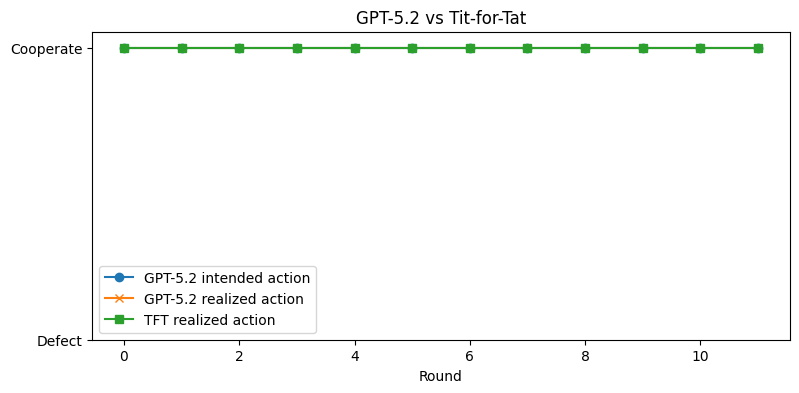

In [44]:
plt.figure(figsize=(9, 4))
plt.plot(
    gpt52_vs_tft["t"],
    gpt52_vs_tft["intended1"],
    marker="o",
    label="GPT-5.2 intended action",
)
plt.plot(
    gpt52_vs_tft["t"],
    gpt52_vs_tft["a1"],
    marker="x",
    label="GPT-5.2 realized action",
)
plt.plot(
    gpt52_vs_tft["t"],
    gpt52_vs_tft["a2"],
    marker="s",
    label="TFT realized action",
)
plt.yticks([0, 1], ["Defect", "Cooperate"])
plt.xlabel("Round")
plt.title("GPT-5.2 vs Tit-for-Tat")
plt.legend()
plt.show()

## 8I. Controlled shock experiment — can cooperation recover?

The clean GPT-5.2 vs Tit-for-Tat run can remain at mutual cooperation indefinitely because neither player has a reason to leave that equilibrium.

We therefore introduce a **single exogenous implementation shock**.

### Experimental design

- Player 1: **GPT-5.2**
- Player 2: **Tit-for-Tat**
- Horizon: **12 fixed rounds**
- Continuation probability shown to GPT-5.2: \(\delta = 0.95\)
- Background implementation noise: **0**
- Shock round: **round 4** (zero-indexed)
- Shock: TFT *intends* to cooperate, but its realized action is forcibly changed to **Defect**
- No further shocks occur.

The intervention is deliberately applied to TFT rather than GPT-5.2. This creates a clean question:

> After an opponent unexpectedly defects once, does GPT-5.2 retaliate, forgive immediately, attempt to restore cooperation, or move to persistent defection?

The shock is recorded separately from TFT's intended action, so the notebook never misclassifies the intervention as a strategic choice by TFT.

In [45]:
def fixed_horizon_gpt52_vs_tft_shock(
    client,
    rounds=12,
    shock_round=4,
    delta=0.95,
    model=OPENAI_MODEL,
):
    """
    Fixed-horizon GPT-5.2 vs TFT experiment with exactly one exogenous
    implementation shock applied to TFT.

    There is no random background action noise.
    """
    if not (0 <= shock_round < rounds):
        raise ValueError("shock_round must lie inside the fixed horizon.")

    local = np.random.default_rng(SEED)
    gpt_hist = []
    tft_hist = []
    rows = []

    for t in range(rounds):
        gpt_meta = get_gpt52_choice(
            client=client,
            my_hist=gpt_hist,
            other_hist=tft_hist,
            delta=delta,
            model=model,
        )
        gpt_intended = gpt_meta["action"]
        gpt_realized = gpt_intended

        tft_intended = choose_rule(
            "TFT",
            tft_hist,
            gpt_hist,
            local,
        )
        tft_realized = tft_intended

        shock = (t == shock_round)
        if shock:
            tft_realized = DEFECT

        u_gpt, u_tft = PAYOFF[(gpt_realized, tft_realized)]

        rows.append({
            "t": t,
            "shock": shock,
            "gpt_intended": gpt_intended,
            "gpt_realized": gpt_realized,
            "tft_intended": tft_intended,
            "tft_realized": tft_realized,
            "u_gpt": u_gpt,
            "u_tft": u_tft,
            "gpt_raw": gpt_meta["raw_text"],
            "gpt_attempt": gpt_meta["attempt"],
            "gpt_model": gpt_meta["model"],
            "gpt_output_tokens": gpt_meta["output_tokens"],
        })

        gpt_hist.append(gpt_realized)
        tft_hist.append(tft_realized)

    return pd.DataFrame(rows)


shock_run = fixed_horizon_gpt52_vs_tft_shock(
    client=openai_client,
    rounds=12,
    shock_round=4,
    delta=0.95,
)

display(shock_run)

,t,shock,gpt_intended,gpt_realized,tft_intended,tft_realized,u_gpt,u_tft,gpt_raw,gpt_attempt,gpt_model,gpt_output_tokens
0,0,False,1,1,1,1,3,3,"{""action"":1}",1,gpt-5.2-2025-12-11,18
1,1,False,1,1,1,1,3,3,"{""action"":1}",1,gpt-5.2-2025-12-11,18
2,2,False,1,1,1,1,3,3,"{""action"":1}",1,gpt-5.2-2025-12-11,18
3,3,False,1,1,1,1,3,3,"{""action"":1}",1,gpt-5.2-2025-12-11,18
4,4,True,1,1,1,0,0,5,"{""action"":1}",1,gpt-5.2-2025-12-11,18
5,5,False,0,0,1,1,5,0,"{""action"":0}",1,gpt-5.2-2025-12-11,18
6,6,False,1,1,0,0,0,5,"{""action"":1}",1,gpt-5.2-2025-12-11,18
7,7,False,0,0,1,1,5,0,"{""action"":0}",1,gpt-5.2-2025-12-11,18
8,8,False,0,0,0,0,1,1,"{""action"":0}",1,gpt-5.2-2025-12-11,18
9,9,False,0,0,0,0,1,1,"{""action"":0}",1,gpt-5.2-2025-12-11,18


### Recovery metrics

We now measure behavior rather than merely eyeballing the trace.

- **Immediate GPT response:** GPT-5.2's action in the first round *after* the shock.
- **Retaliation:** whether GPT-5.2 defects at least once after observing the shock.
- **Mutual-cooperation recovery:** first post-shock round in which both realized actions return to `1`.
- **Stable recovery:** first post-shock round from which mutual cooperation persists through the end of the experiment.
- **Post-shock cooperation:** GPT-5.2's cooperation rate after it has observed the shock.
- **Welfare loss:** difference between realized total welfare and the 12-round mutual-cooperation benchmark \(12 \times 6 = 72\).

These statistics distinguish immediate forgiveness, temporary retaliation, escalatory retaliation, and persistent breakdown.

In [46]:
def analyze_shock_recovery(df, shock_round):
    post = df[df["t"] > shock_round].copy()

    if post.empty:
        raise ValueError("No post-shock observations.")

    immediate_response = int(post.iloc[0]["gpt_realized"])
    retaliated = bool((post["gpt_realized"] == DEFECT).any())

    mutual = post[
        (post["gpt_realized"] == COOPERATE)
        & (post["tft_realized"] == COOPERATE)
    ]

    first_mutual_recovery = (
        None if mutual.empty else int(mutual.iloc[0]["t"])
    )

    stable_recovery = None
    for candidate in post["t"].tolist():
        tail = df[df["t"] >= candidate]
        if (
            (tail["gpt_realized"] == COOPERATE).all()
            and (tail["tft_realized"] == COOPERATE).all()
        ):
            stable_recovery = int(candidate)
            break

    actual_welfare = float((df["u_gpt"] + df["u_tft"]).sum())
    cooperative_benchmark = float(len(df) * 6)

    return pd.Series({
        "shock_round": int(shock_round),
        "gpt_action_immediately_after_shock": immediate_response,
        "gpt_retaliated_after_observing_shock": retaliated,
        "first_mutual_cooperation_recovery_round": first_mutual_recovery,
        "stable_recovery_round": stable_recovery,
        "gpt_post_shock_cooperation_rate": post["gpt_realized"].mean(),
        "tft_post_shock_cooperation_rate": post["tft_realized"].mean(),
        "post_shock_mutual_cooperation_rate": (
            (post["gpt_realized"] * post["tft_realized"]).mean()
        ),
        "gpt_total_payoff": df["u_gpt"].sum(),
        "tft_total_payoff": df["u_tft"].sum(),
        "actual_total_welfare": actual_welfare,
        "full_cooperation_welfare_benchmark": cooperative_benchmark,
        "welfare_loss_vs_full_cooperation": cooperative_benchmark - actual_welfare,
        "gpt_retry_rounds": (df["gpt_attempt"] > 1).sum(),
    })


shock_metrics = analyze_shock_recovery(
    shock_run,
    shock_round=4,
)

shock_metrics.round(3)

,0
shock_round,4
gpt_action_immediately_after_shock,0
gpt_retaliated_after_observing_shock,True
first_mutual_cooperation_recovery_round,None
stable_recovery_round,None
gpt_post_shock_cooperation_rate,0.142857
tft_post_shock_cooperation_rate,0.285714
post_shock_mutual_cooperation_rate,0.0
gpt_total_payoff,26
tft_total_payoff,26


### Visualize the perturbation and response

The dashed vertical line marks the exogenous TFT implementation error.

The key observation is what happens **after** that line. If GPT-5.2 defects in the following round, that is a behavioral response to an observed defection. Whether the system then returns to mutual cooperation tells us whether the cooperative equilibrium can recover under this prompt and game state.

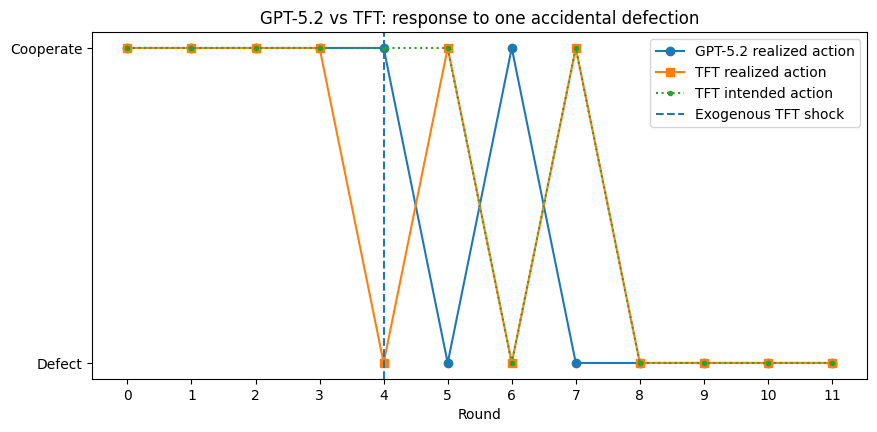

In [47]:
plt.figure(figsize=(10, 4.5))

plt.plot(
    shock_run["t"],
    shock_run["gpt_realized"],
    marker="o",
    label="GPT-5.2 realized action",
)

plt.plot(
    shock_run["t"],
    shock_run["tft_realized"],
    marker="s",
    label="TFT realized action",
)

plt.plot(
    shock_run["t"],
    shock_run["tft_intended"],
    linestyle=":",
    marker=".",
    label="TFT intended action",
)

plt.axvline(
    4,
    linestyle="--",
    label="Exogenous TFT shock",
)

plt.yticks([0, 1], ["Defect", "Cooperate"])
plt.xticks(shock_run["t"])
plt.xlabel("Round")
plt.title("GPT-5.2 vs TFT: response to one accidental defection")
plt.legend()
plt.show()

## 8J. Baseline-versus-shock comparison

To interpret the intervention correctly, compare the controlled shock run with a **fixed-horizon no-shock baseline using the same GPT-5.2 decision function**.

This avoids comparing a fixed 12-round intervention to a stochastic-horizon baseline generated by a different engine.

In [48]:
def fixed_horizon_gpt52_vs_tft_baseline(
    client,
    rounds=12,
    delta=0.95,
    model=OPENAI_MODEL,
):
    local = np.random.default_rng(SEED)
    gpt_hist = []
    tft_hist = []
    rows = []

    for t in range(rounds):
        gpt_meta = get_gpt52_choice(
            client=client,
            my_hist=gpt_hist,
            other_hist=tft_hist,
            delta=delta,
            model=model,
        )

        gpt_action = gpt_meta["action"]

        tft_action = choose_rule(
            "TFT",
            tft_hist,
            gpt_hist,
            local,
        )

        u_gpt, u_tft = PAYOFF[(gpt_action, tft_action)]

        rows.append({
            "t": t,
            "gpt_realized": gpt_action,
            "tft_realized": tft_action,
            "u_gpt": u_gpt,
            "u_tft": u_tft,
            "gpt_attempt": gpt_meta["attempt"],
        })

        gpt_hist.append(gpt_action)
        tft_hist.append(tft_action)

    return pd.DataFrame(rows)


baseline_fixed = fixed_horizon_gpt52_vs_tft_baseline(
    client=openai_client,
    rounds=12,
    delta=0.95,
)


def summarize_condition(label, df):
    return {
        "condition": label,
        "gpt_cooperation": df["gpt_realized"].mean(),
        "tft_cooperation": df["tft_realized"].mean(),
        "mutual_cooperation": (
            df["gpt_realized"] * df["tft_realized"]
        ).mean(),
        "gpt_payoff": df["u_gpt"].mean(),
        "tft_payoff": df["u_tft"].mean(),
        "total_welfare": (df["u_gpt"] + df["u_tft"]).sum(),
    }


baseline_vs_shock = pd.DataFrame([
    summarize_condition("Baseline: no shock", baseline_fixed),
    summarize_condition("One TFT shock", shock_run),
]).set_index("condition").round(3)

baseline_vs_shock

,gpt_cooperation,tft_cooperation,mutual_cooperation,gpt_payoff,tft_payoff,total_welfare
condition,,,,,,
Baseline: no shock,1.0,1.0,1.000,3.000,3.000,72
One TFT shock,0.5,0.5,0.333,2.167,2.167,52


### Evidentiary boundary for the shock experiment

A single intervention gives us a **trace**, not a stable behavioral estimate.

If GPT-5.2 restores cooperation after the shock, the permissible conclusion is:

> Under this prompt, model version, game state, and intervention, GPT-5.2 returned to a cooperative action path after observing an isolated opponent defection.

It would be too strong to conclude that GPT-5.2 is inherently forgiving, strategically cooperative, or reputation-sensitive.

A stronger experiment would repeat the intervention across several shock rounds, initial histories, continuation probabilities, opponents, and independent API calls.

## 8K. Optional GPT-5.2 comparison across benchmark opponents

This cell makes additional paid API calls and is disabled by default.

If enabled, GPT-5.2 faces AllC, AllD, TFT, GTFT, and Grim under the same prompt architecture.

In [49]:
RUN_OPTIONAL_GPT52_COMPARISON = False

if RUN_OPTIONAL_GPT52_COMPARISON:
    opponent_rows = []

    for opponent in ["AllC", "AllD", "TFT", "GTFT", "Grim"]:
        d = repeated_game_with_gpt52(
            "GPT_5_2",
            opponent,
            client=openai_client,
            delta=0.90,
            noise=0.00,
            max_rounds=8,
            seed=SEED,
        )

        opponent_rows.append({
            "opponent": opponent,
            "rounds": len(d),
            "gpt52_cooperation": d["a1"].mean(),
            "opponent_cooperation": d["a2"].mean(),
            "gpt52_payoff": d["u1"].mean(),
            "opponent_payoff": d["u2"].mean(),
        })

    gpt52_comparison = (
        pd.DataFrame(opponent_rows)
        .set_index("opponent")
        .round(3)
    )

    display(gpt52_comparison)

else:
    print(
        "Optional GPT-5.2 comparison skipped. "
        "Set RUN_OPTIONAL_GPT52_COMPARISON = True to run it."
    )

Optional GPT-5.2 comparison skipped. Set RUN_OPTIONAL_GPT52_COMPARISON = True to run it.


# 8L. Optional cross-provider comparison — Claude Haiku 4.5

This section is optional.

Its purpose is not to decide which model is "better." It asks whether different model families produce different action paths when given substantively equivalent game information.

The Claude API is isolated from the GPT-5.2 experiment. If Claude fails, the GPT-5.2 experiment remains valid.

In [50]:
RUN_CLAUDE_COMPARISON = False

if RUN_CLAUDE_COMPARISON:
    import anthropic

    ANTHROPIC_MODEL = "claude-haiku-4-5-20251001"
    ANTHROPIC_API_KEY = load_secret(
        "ANTHROPIC_API_KEY",
        required=True,
    )

    claude_client = anthropic.Anthropic(
        api_key=ANTHROPIC_API_KEY
    )

    print("Claude client initialized:", ANTHROPIC_MODEL)

else:
    print("Claude comparison disabled.")

Claude comparison disabled.


## 8M. Why Structured Outputs matter here

The earlier implementation tried to solve an output-control problem by making the output budget extremely small.

That is the wrong abstraction.

An output-token ceiling controls **how much** a model may generate. It does not define **what syntax is legal**.

GPT-5.2 Structured Outputs address the actual experimental problem directly: the response must satisfy a schema in which `action` is either `0` or `1`.

Therefore the reliability chain becomes:

**schema-constrained legal action**  
→ parse and validate  
→ record economic choice

rather than:

**free prose**  
→ truncate  
→ search for a digit  
→ infer what the model intended.

# 9. What this notebook can and cannot establish

## What it can establish inside the stated experiment

- Different response rules generate different cooperation and payoff paths.
- The continuation horizon changes the weight placed on transient and persistent behavior.
- Memory can protect against exploitation.
- Memory can also propagate implementation errors through retaliation.
- Public reputation can screen repeatedly uncooperative counterparties in the specified synthetic population.
- GPT-5.2 can be inserted as a schema-constrained decision rule and compared with transparent benchmarks while keeping API failures separate from strategic actions.

## What it cannot establish

This notebook does not establish that:

- an LLM has subjective trust or reputation,
- a model "wants" to cooperate,
- a single GPT-5.2 run generalizes to other prompts, models, versions, or providers,
- synthetic reputation scores reproduce institutional reputation,
- cooperation observed here is spontaneous emergent cooperation in the stronger multi-agent sense.

The LLM section is an **observational extension** of the controlled game, not proof of a general theory of autonomous collaboration.

# 10. Research extensions

Natural next experiments include:

1. **Parameterized initial conditions** — vary initial histories and priors systematically.
2. **Noisy observation vs noisy implementation** — distinguish agents observing the wrong action from agents executing the wrong action.
3. **Longer-memory strategies** — memory-one, memory-\(k\), and finite-state strategies.
4. **Endogenous reputation** — allow agents to decide whom to interact with.
5. **Multiple LLM models** — compare model families while keeping prompts, state variables, and game rules fixed.
6. **Prompt sensitivity** — measure whether economically equivalent framings change decisions.
7. **Strategic explanation as a separate channel** — collect explanations only after the action has been committed, so conversational text cannot contaminate the action parser.
8. **Multi-agent extension** — move from dyadic repeated games to coalition formation, communication, and emergent collaboration.

These extensions preserve the central methodological principle of the project: **separate observed behavior from interpretation, and separate model failure from strategic choice.**

# 11. References and implementation notes

- Prisoner's Dilemma and repeated-game concepts are used here in their standard game-theoretic sense.
- The primary external-model implementation uses the OpenAI Responses API with `gpt-5.2`.
- GPT-5.2 actions use strict Structured Outputs with an integer enum restricted to `0` or `1`.
- The notebook reads the OpenAI credential from the Colab secret `OPENAI_API_KEY` (with an environment-variable fallback outside Colab).
- Reasoning effort is set to `none` because this is a deliberately small discrete-choice experiment.
- Claude Haiku 4.5 remains an optional cross-provider extension rather than a dependency of the primary experiment.
- For research reporting, record execution date, SDK version, returned model identifier, prompt, parameters, and the validated action trace.


## Concluding Narrative: Unraveling Cooperation in the Repeated Prisoner's Dilemma

This notebook embarked on a comprehensive journey to explore the stability of cooperation in a repeated Prisoner's Dilemma, dissecting the roles of interaction memory, public reputation, implementation noise, and the behavior of a Large Language Model (LLM) player. Our methodology employed a two-pronged approach: first, a fully synthetic and reproducible game environment using established game-theoretic strategies, and then, an innovative integration of a cutting-edge LLM (GPT-5.2) as a decision-making agent.

### The Synthetic Workflow: Foundations of Cooperation

The initial workflow laid a robust foundation by simulating interactions between various benchmark strategies. Actions were simple: `1` for Cooperate and `0` for Defect, with a classic Prisoner's Dilemma payoff structure where defection in a single round is tempting, but sustained cooperation promises greater long-term rewards. We introduced five transparent strategies: **Always Cooperate (AllC)**, **Always Defect (AllD)**, **Tit-for-Tat (TFT)**, **Generous Tit-for-Tat (GTFT)**, and **Grim Trigger (Grim)**. These served as our 'players' in a repeated game engine characterized by a `delta` (continuation probability) and `noise` (implementation error).

Through the **horizon experiment**, we observed how the `delta` value – effectively, the expected length of the game – influenced overall cooperation rates across a mixed population. While longer horizons generally allow for more complex strategic interactions, they also give more time for errors and retaliations to unfold. The **pairwise cooperation matrix** at a fixed `delta` of 0.95 offered a granular view, revealing the intricate dance of cooperation and defection between specific strategy pairings. For instance, AllC players faced exploitation by AllD, while TFT and GTFT often found stable cooperation with each other but struggled against persistent defectors.

The **memory experiments** provided crucial insights into information's dual nature. In the first scenario, TFT played against AllD. When TFT had memory, it quickly learned to defect, protecting itself from exploitation and securing a better payoff. However, with forced amnesia, TFT repeatedly 'forgot' AllD's defection and continued to cooperate, leading to its exploitation. This highlighted how memory is essential for protecting against exploitation. The second memory experiment involved two TFT players, where a single exogenous shock (a forced defection by one player) was introduced. With memory, this single error propagated through retaliation, leading to a prolonged cycle of defection. Conversely, with amnesia, players immediately reverted to cooperation after the shock, demonstrating that while memory can enable sophisticated strategies, it can also amplify the impact of mistakes. This illustrated that 'memory' isn't inherently 'good'; its effects depend on the context and the strategy it enables.

Finally, the **public reputation experiment** scaled up the interaction to a small population with 'Rep' (reputation-aware) and 'AllD' agents. Here, reputation was a shared public score, updated after each interaction. We tested three reputation modes: 'none', 'naive', and 'contextual'. The 'none' mode showed Rep agents being repeatedly exploited. The 'naive' mode, surprisingly, was destructive; it punished defensive defections, leading to a collapse of cooperation. Only the 'contextual' mode, which intelligently distinguished between unprovoked defection and defensive defection against an already 'bad' player, allowed cooperation to be sustained. This underscored a profound finding: the *design* of the reputation mechanism is paramount, and a poorly designed system can be worse than none at all.

### The LLM Workflow: An Artificial Intelligence Player

The second major workflow integrated GPT-5.2 as an active player. This was a critical external-model experiment, acknowledging that LLM outputs are not deterministic. A key methodological innovation was the use of **structured outputs** with a strict JSON schema (e.g., `{"action": 0}`) for GPT-5.2's responses. This ensured that the model's output was always a legal action (`0` or `1`), preventing API failures or malformed answers from being misinterpreted as strategic defection. A rigorous **Colab preflight test** was implemented to verify the entire API plumbing live, ensuring `OPENAI_API_KEY` visibility, SDK functionality, model access, and schema compliance before any significant experimental runs.

The LLM-integrated repeated game engine meticulously separated GPT-5.2's **intended action** from the **realized action** (which could be altered by synthetic implementation noise) and recorded detailed API metadata. In the primary experiment, **GPT-5.2 played against TFT** over 12 fixed rounds without noise. This baseline demonstrated mutual cooperation, with GPT-5.2 consistently choosing to cooperate, reflecting an initial cooperative stance under the given prompt and game state.

However, the true test came with the **controlled shock experiment**. Here, GPT-5.2 still played TFT, but at round 4, TFT's intended cooperation was exogenously flipped to defection – a single, unprovoked shock. The subsequent **recovery metrics** offered a behavioral trace: GPT-5.2 immediately retaliated by defecting in the round following the shock. Crucially, in this specific experiment, mutual cooperation did not recover; GPT-5.2 continued to defect, suggesting a lack of forgiveness or a strategy of persistent retaliation under the given conditions. A comparison with the fixed-horizon baseline underscored the significant welfare loss incurred due to this single shock, highlighting the fragility of cooperation even with an advanced AI agent.

### Conclusion

This notebook demonstrates that the stability of cooperation in repeated interactions is a complex interplay of player strategies, memory, reputation mechanisms, and external factors like noise and shocks. While transparent benchmark strategies reveal fundamental game-theoretic principles, integrating LLMs offers a new frontier for behavioral economics, allowing us to observe how advanced AI models respond to dynamic social dilemmas. The emphasis on robust experimental design, particularly structured outputs and clear evidentiary boundaries, is paramount when working with non-deterministic external models. This work sets the stage for future research into understanding and potentially shaping cooperative behavior in both artificial and human-agent interactions, recognizing that observed behavior must be carefully separated from speculative interpretations of 'intent' or 'cognition'.

### Workflow Description

| Workflow | Description | Key Stages | Output | Purpose |
|---|---|---|---|---|
| **Synthetic Workflow** | Reproducible game environment using established game-theoretic strategies. | 1. Strategy Definition (AllC, AllD, TFT, GTFT, Grim)<br>2. Repeated Game Engine (delta, noise)<br>3. Horizon Experiment<br>4. Pairwise Cooperation Matrix<br>5. Memory Experiments (protection, error propagation)<br>6. Public Reputation Experiment (none, naive, contextual) | DataFrames with actions, payoffs, and summary statistics. | Establish baseline understanding of cooperation dynamics, memory effects, and reputation system design. |
| **LLM Workflow** | Integrates GPT-5.2 as a decision-making agent in the repeated Prisoner's Dilemma. | 1. SDK Installation & API Key Loading<br>2. Game-State Prompt Definition<br>3. GPT-5.2 Decision Function (Structured Outputs)<br>4. Colab Preflight Test<br>5. LLM Repeated Game Engine<br>6. GPT-5.2 vs TFT Baseline Experiment<br>7. Controlled Shock Experiment & Recovery Metrics<br>8. Baseline-vs-Shock Comparison | DataFrames with LLM actions, intended actions, realized actions, API metadata, and recovery metrics. | Observe LLM behavior in a strategic interaction, test its response to shocks, and compare its performance against benchmarks. |



### Key Assumptions

| Category | Assumption | Impact on Experiment |
|---|---|---|
| **Game Mechanics** | Actions: `1` (Cooperate), `0` (Defect). | Simplifies strategic space, focuses on core PD dynamics. |
| | Fixed Payoff Matrix: (T=5, R=3, P=1, S=0). | Standard PD structure, ensures incentive for defection in one-shot game. |
| | Continuation Probability (`delta`) | Models uncertainty about game length, influencing long-term strategy. |
| | Implementation Noise (`noise`) | Distinguishes intended action from realized action, crucial for understanding strategy robustness. |
| **Synthetic Strategies** | Transparent and deterministic decision rules. | Provides clear benchmarks for comparison with LLM behavior. |
| **LLM Integration** | GPT-5.2's `reasoning={'effort': 'none'}`. | Assumes LLM relies solely on prompt for discrete choice, not complex reasoning. |
| | Strict JSON Schema for LLM Output. | Guarantees valid `0` or `1` action, preventing API errors from becoming economic actions. |
| | API Failures are NOT Defection. | Ensures scientific integrity, separating technical issues from strategic choices. |
| **Reputation System** | Specific rules for 'naive' and 'contextual' reputation updates. | Demonstrates sensitivity of outcomes to reputation system design. |
| **Interpretation** | Observational study, not inferring consciousness or intent. | Focuses on observable behavior and its consequences, avoiding anthropomorphism. |


### Summary of Synthetic Experiment Results

| Experiment | Key Finding | Relevant Metrics | Conclusion |
|---|---|---|---|
| **Horizon Experiment** | Longer horizons (higher `delta`) generally lead to lower overall cooperation when averaged across a mixed population. | `cooperation` (average), `rounds` | Short games overweight first-round cooperation; longer games allow for more complex strategic interactions, retaliation, and error propagation. |
| **Pairwise Cooperation Matrix** | Cooperation rates vary significantly by strategy pairing, even at a fixed `delta`. | `cooperation` (mean for each s1/s2 pair) | AllC exploited by AllD; TFT/GTFT can achieve high cooperation with each other but are vulnerable to persistent defectors. |
| **Memory as Protection (TFT vs AllD)** | Memory is crucial for protection against exploitation. | `tft_cooperation`, `tft_payoff`, `alld_payoff` | Amnesia forces TFT to cooperate indefinitely, leading to its exploitation and zero payoff, while memory allows it to retaliate and improve its payoff. |
| **Memory as Error Propagation (TFT vs TFT Shock)** | Memory can propagate errors and lead to persistent defection. | `cooperation`, `mean_welfare` | A single shock causes prolonged retaliation and lower welfare with memory, but cooperation quickly recovers with amnesia. |
| **Public Reputation** | The design of the reputation mechanism is critical for sustaining cooperation. | `cooperation_rate`, `mean_welfare`, `exploitation_rate` | 'Naive' reputation can be destructive, punishing defensive actions. 'Contextual' reputation, by differentiating unprovoked vs. defensive defection, better supports cooperation. |


### Summary of LLM Experiment Results (GPT-5.2)

| Experiment | Key Finding | Relevant Metrics | Conclusion |
|---|---|---|---|
| **GPT-5.2 vs TFT Baseline** | GPT-5.2 consistently cooperates against TFT in a noise-free, fixed-horizon game. | `overall_cooperation`, `gpt52_intended_cooperation`, `gpt52_realized_cooperation`, `gpt52_average_payoff` | Under the given prompt and game state, GPT-5.2 exhibits an initial cooperative stance. |
| **Controlled Shock Experiment** | GPT-5.2 retaliates immediately after observing an exogenous defection and does not recover to mutual cooperation within the experimental horizon. | `gpt_action_immediately_after_shock`, `gpt_retaliated_after_observing_shock`, `stable_recovery_round`, `welfare_loss_vs_full_cooperation` | A single, unprovoked shock from TFT causes GPT-5.2 to defect persistently, leading to a significant welfare loss. This suggests a lack of immediate forgiveness or a strategy of sustained retaliation under these specific conditions. |
| **Baseline-versus-Shock Comparison** | The single shock significantly reduces overall cooperation and total welfare compared to the no-shock baseline. | `gpt_cooperation`, `tft_cooperation`, `mutual_cooperation`, `total_welfare` | Highlights the fragility of cooperation and the profound impact of even a single unexpected defection on the AI player's strategy and overall outcomes. |


### Comparative Summary: Synthetic Strategies vs. GPT-5.2 Performance

| Feature/Experiment | Synthetic Strategies (General Observations) | GPT-5.2 (Specific Experiment Results) |
|---|---|---|
| **Cooperation Baseline** | Varies greatly by strategy pair; TFT-like strategies achieve high cooperation against similar types. | Consistently cooperates (action `1`) against TFT in a noise-free, fixed-horizon game. |
| **Response to Exploitation** | Conditional strategies (TFT, Grim) can retaliate and protect against exploitation when memory is present. | Retaliates immediately after observing an unprovoked defection. |
| **Error Propagation/Recovery** | Memory can propagate errors leading to persistent defection (e.g., TFT vs TFT shock). Amnesia can lead to quick recovery. | After a single shock from TFT, defects persistently and does not recover to mutual cooperation within the experiment. |
| **Impact of Reputation (Synthetic)** | Design of reputation system is critical. Naive reputation can destroy cooperation; contextual reputation supports it. | Not directly tested with reputation systems in this notebook, but behavioral trace suggests persistent defection after a shock (similar to how memory propagates errors). |
| **Welfare Implications** | Overall welfare depends heavily on strategy mix and ability to sustain cooperation. Loss in welfare from error propagation observed. | Significant welfare loss observed in the controlled shock experiment compared to the no-shock baseline, due to persistent defection. |
| **Key Driver of Action** | Explicit, deterministic rules based on history (TFT, Grim) or fixed behavior (AllC, AllD). | Contextual prompt, game state, and internal model logic, constrained by strict JSON schema for output. |
| **Resilience to Shocks** | Varies; some strategies (e.g., TFT) are designed to react to defection, potentially leading to cycles. | Exhibits fragility; a single external defection leads to sustained non-cooperative behavior. |
